<a href="https://colab.research.google.com/github/2303A51621/SE-RA/blob/main/lab%202%20assignment%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset loaded successfully!
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)

After preprocessing:
Training images: (60000, 28, 28, 1)
Testing images : (10000, 28, 28, 1)


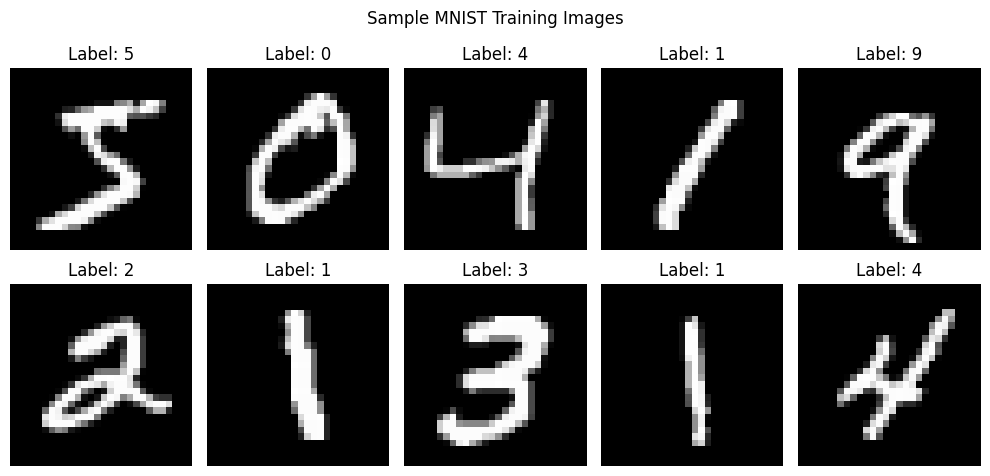

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - accuracy: 0.9319 - loss: 0.2255 - val_accuracy: 0.9792 - val_loss: 0.0840
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9804 - loss: 0.0642 - val_accuracy: 0.9852 - val_loss: 0.0514
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9867 - loss: 0.0441 - val_accuracy: 0.9887 - val_loss: 0.0414
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9899 - loss: 0.0328 - val_accuracy: 0.9887 - val_loss: 0.0404
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9911 - loss: 0.0272 - val_accuracy: 0.9898 - val_loss: 0.0392


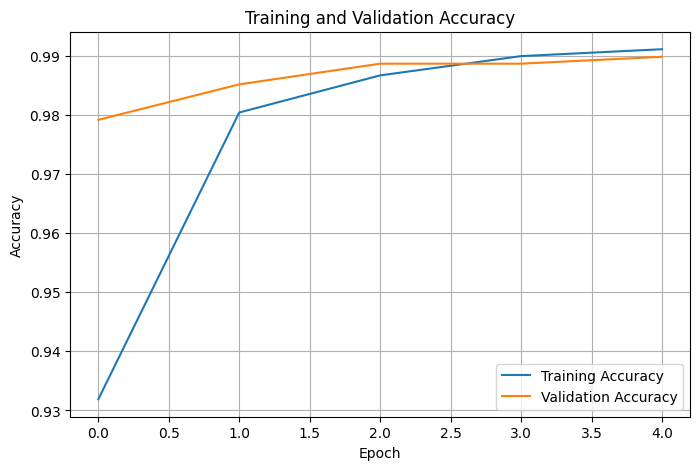

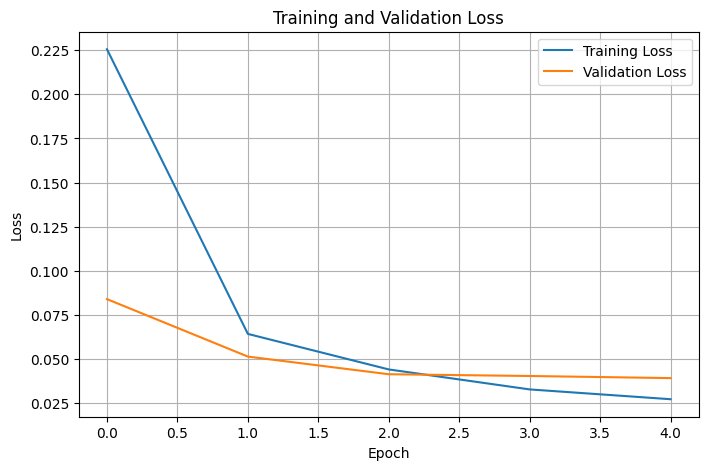


CLEAN TEST DATA EVALUATION
Test Loss     : 0.036218952387571335
Test Accuracy : 0.9886999726295471

BASELINE MODEL PERFORMANCE
Accuracy  : 0.9887
Precision : 0.9888
Recall    : 0.9887
F1-Score  : 0.9887

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.98      0.98       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.97      0.98       974
           9       0.98      1.00      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



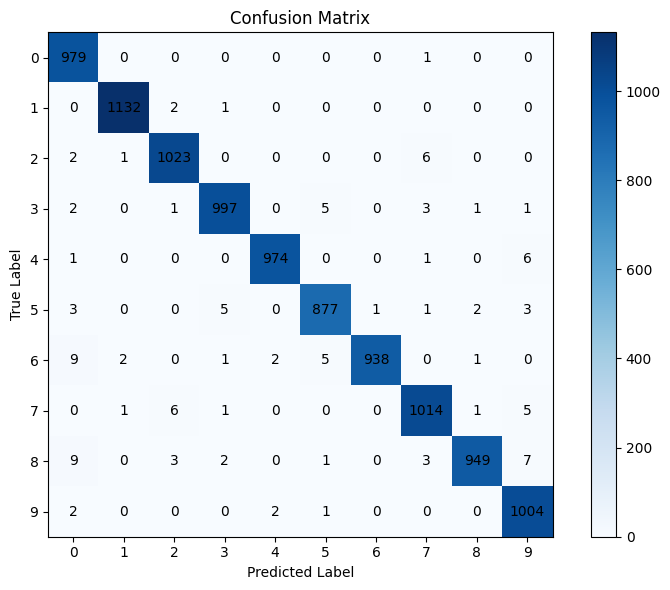


Number of correctly classified images: 9887


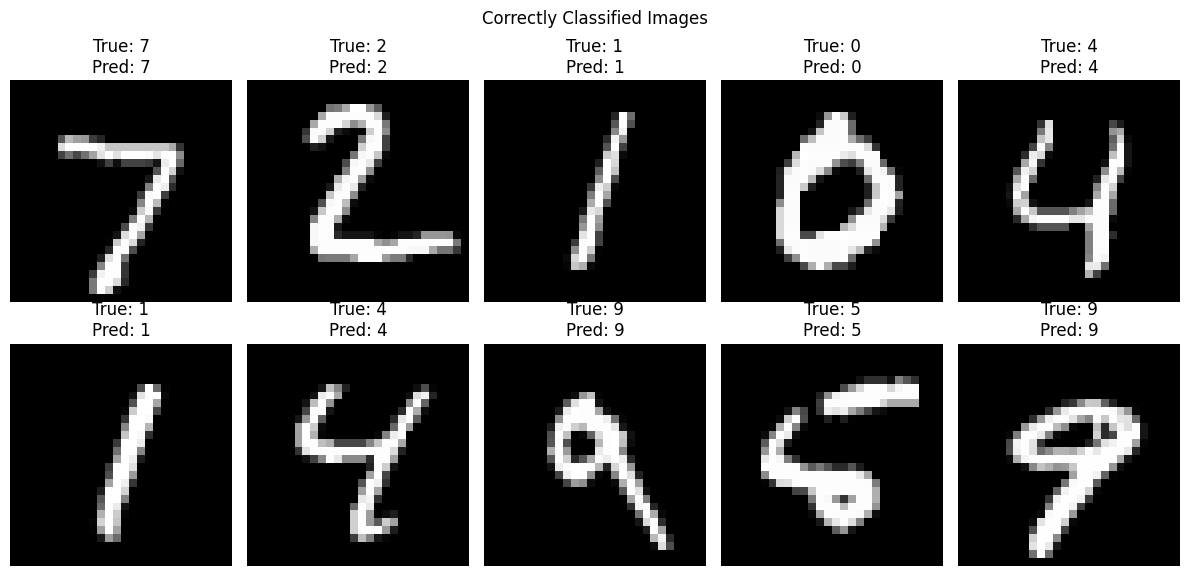

Number of incorrectly classified images: 113


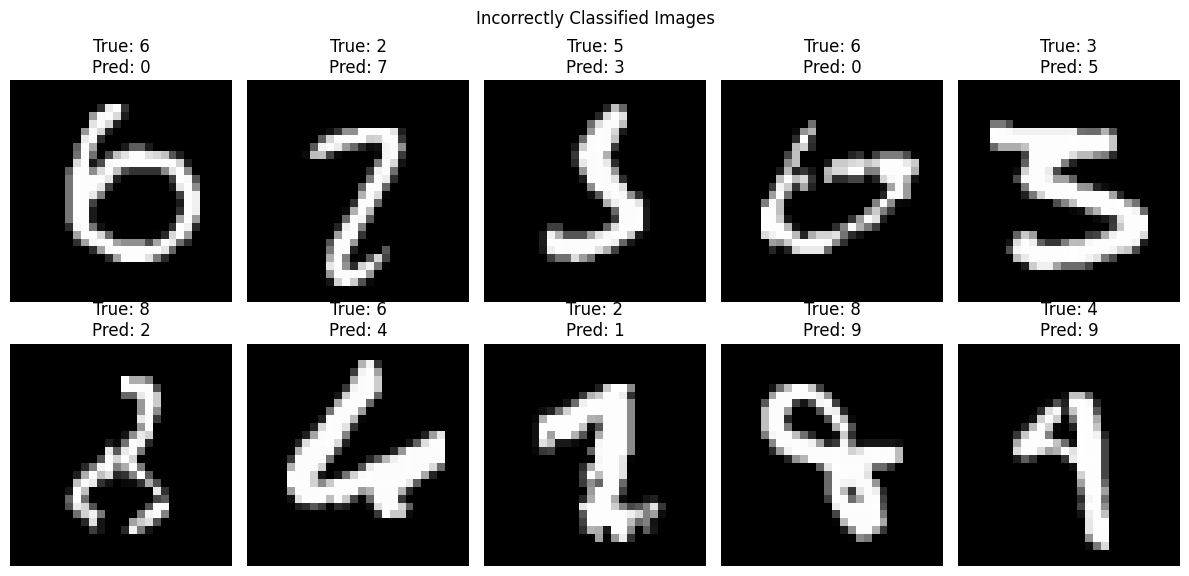


BASELINE RESULTS RECORDED
Dataset       : MNIST
Model         : Basic CNN
Test Images   : 10,000
Accuracy      : 0.9887
Precision     : 0.9888
Recall        : 0.9887
F1-Score      : 0.9887

These values represent the CLEAN BASELINE
before any adversarial perturbation.


In [1]:
# ============================================================
# IMAGE CLASSIFIER SETUP AND BASELINE EVALUATION
# Dataset: MNIST
# Model: Basic Convolutional Neural Network (CNN)
# ============================================================

# STEP 1: IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)


# ============================================================
# STEP 2: LOAD MNIST DATASET
# ============================================================

(train_images, train_labels), (test_images, test_labels) = \
    tf.keras.datasets.mnist.load_data()

print("\nDataset loaded successfully!")

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Testing images :", test_images.shape)
print("Testing labels :", test_labels.shape)


# ============================================================
# STEP 3: PREPROCESS THE DATA
# ============================================================

# Normalize pixel values from 0-255 to 0-1
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Add channel dimension
# From: (60000, 28, 28)
# To:   (60000, 28, 28, 1)

train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

print("\nAfter preprocessing:")
print("Training images:", train_images.shape)
print("Testing images :", test_images.shape)


# ============================================================
# STEP 4: DISPLAY SAMPLE TRAINING IMAGES
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i].squeeze(), cmap="gray")
    plt.title("Label: " + str(train_labels[i]))
    plt.axis("off")

plt.suptitle("Sample MNIST Training Images")
plt.tight_layout()
plt.show()


# ============================================================
# STEP 5: BUILD CNN MODEL
# ============================================================

model = models.Sequential([

    # First convolution layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Pooling layer
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Pooling layer
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Output layer - 10 classes
    layers.Dense(10, activation="softmax")
])


# ============================================================
# STEP 6: DISPLAY MODEL ARCHITECTURE
# ============================================================

model.summary()


# ============================================================
# STEP 7: COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# STEP 8: TRAIN THE CNN
# ============================================================

history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


# ============================================================
# STEP 9: PLOT TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# STEP 10: PLOT TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# STEP 11: EVALUATE MODEL ON CLEAN TEST IMAGES
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print("\n========================================")
print("CLEAN TEST DATA EVALUATION")
print("========================================")

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)


# ============================================================
# STEP 12: MAKE PREDICTIONS
# ============================================================

predictions = model.predict(
    test_images,
    verbose=0
)

# Convert probability predictions into class labels
predicted_labels = np.argmax(predictions, axis=1)


# ============================================================
# STEP 13: CALCULATE PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    test_labels,
    predicted_labels
)

precision = precision_score(
    test_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    test_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    test_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)


# ============================================================
# STEP 14: DISPLAY BASELINE PERFORMANCE
# ============================================================

print("\n========================================")
print("BASELINE MODEL PERFORMANCE")
print("========================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("========================================")


# ============================================================
# STEP 15: CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT")
print("=====================")

print(
    classification_report(
        test_labels,
        predicted_labels,
        zero_division=0
    )
)


# ============================================================
# STEP 16: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    predicted_labels
)

plt.figure(figsize=(8, 6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================================
# STEP 17: FIND CORRECTLY CLASSIFIED IMAGES
# ============================================================

correct_indices = np.where(
    predicted_labels == test_labels
)[0]

print("\nNumber of correctly classified images:",
      len(correct_indices))


# ============================================================
# STEP 18: DISPLAY CORRECTLY CLASSIFIED IMAGES
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(10):

    index = correct_indices[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        test_images[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        "True: " + str(test_labels[index]) +
        "\nPred: " + str(predicted_labels[index])
    )

    plt.axis("off")

plt.suptitle("Correctly Classified Images")
plt.tight_layout()
plt.show()


# ============================================================
# STEP 19: FIND INCORRECTLY CLASSIFIED IMAGES
# ============================================================

incorrect_indices = np.where(
    predicted_labels != test_labels
)[0]

print("Number of incorrectly classified images:",
      len(incorrect_indices))


# ============================================================
# STEP 20: DISPLAY INCORRECTLY CLASSIFIED IMAGES
# ============================================================

plt.figure(figsize=(12, 6))

number_to_display = min(10, len(incorrect_indices))

for i in range(number_to_display):

    index = incorrect_indices[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        test_images[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        "True: " + str(test_labels[index]) +
        "\nPred: " + str(predicted_labels[index])
    )

    plt.axis("off")

plt.suptitle("Incorrectly Classified Images")
plt.tight_layout()
plt.show()


# ============================================================
# STEP 21: SAVE BASELINE RESULTS
# ============================================================

print("\n========================================")
print("BASELINE RESULTS RECORDED")
print("========================================")

print("Dataset       : MNIST")
print("Model         : Basic CNN")
print("Test Images   : 10,000")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-Score      : {f1:.4f}")

print("\nThese values represent the CLEAN BASELINE")
print("before any adversarial perturbation.")
print("========================================")